[       0.          8333333.33333333 16666666.66666667 25000000.
 25000000.         25000000.         25000000.         25000000.
 25000000.         25000000.         25000000.        ]
[0.e+00 1.e+07 2.e+07 3.e+07 4.e+07 5.e+07 6.e+07 7.e+07 8.e+07 9.e+07
 1.e+08]
[      0.  100000.  200000.  300000.  400000.  500000.  600000.  700000.
  800000.  900000. 1000000.]
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


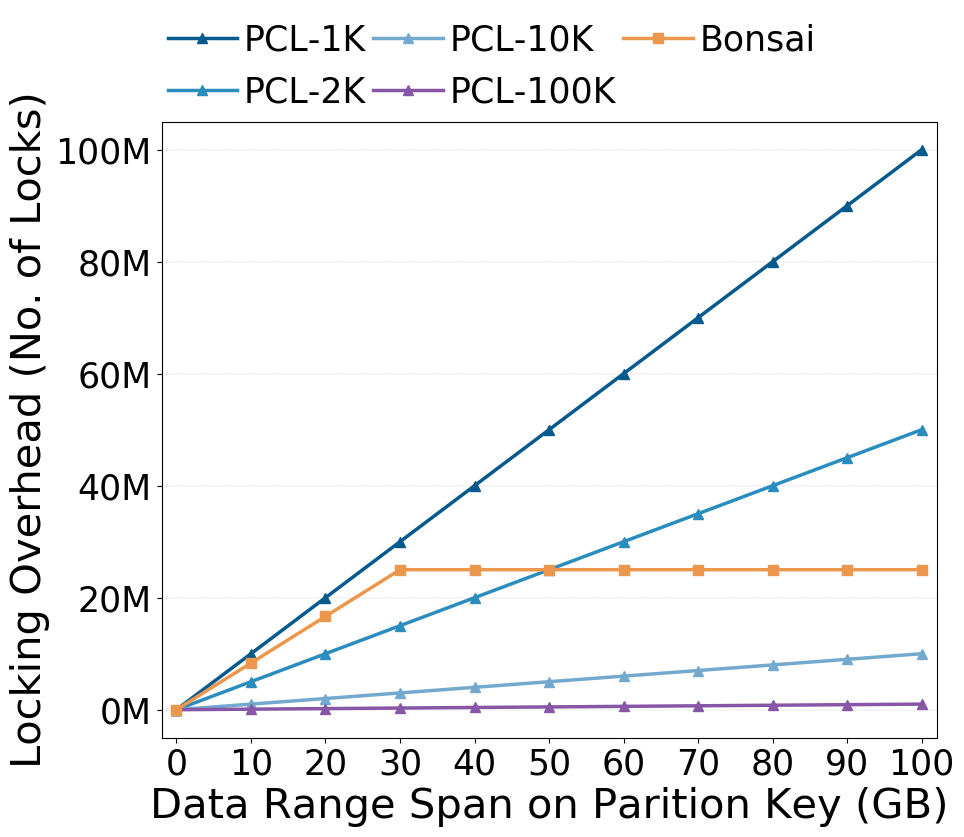

In [39]:
from process_helper import *
import numpy as np
from matplotlib.ticker import FuncFormatter

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)
txtsize=30
ticksize=25


plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5

fig = plt.figure(figsize=(10, 8))

# fig, ax = plt.subplots()
ax = fig.add_subplot(1, 1, 1)

# index = np.arange(1, 11, 1)
# index = np.arange(1, 10.5, 0.5) 
index = np.arange(0, 10.5, 1) 
# tuple_overhead = (np.arange(1, 3, 0.5)/3.0) * (2.5 * 1000*1000)
# tuple_tail = np.repeat(2.5 * 1000*1000, 15)
tuple_overhead = (np.arange(0, 3, 1)/3) * (2.5 * 1000*10000)
tuple_tail = np.repeat(2.5 * 1000*10000, 11 - len(tuple_overhead))

tuple_overhead = np.concatenate((tuple_overhead, tuple_tail), axis=0)

print(tuple_overhead)
# tuple_overhead_75 = (np.arange(1, 9, 0.5)/9.0) * (7.5 * 1000*1000)
# tuple_tail_75 = np.repeat(7.5 * 1000*1000, 3)
# tuple_overhead_75 = np.concatenate((tuple_overhead_75, tuple_tail_75), axis=0)


pcl_1k_overhead = index * 1000 * 10000
pcl_2k_overhead = index * 1000 * 10000/2
pcl_8k_overhead = index * 1000 * 10000/8
pcl_10k_overhead = index * 1000 * 1000
pcl_100k_overhead = index * 1000 * 100
pcl_1M_overhead = index * 10000
pcl_10M_overhead = index * 1000

print(pcl_1k_overhead)

print(pcl_100k_overhead)

print(index)

# ticks = np.array(df_partition_lock["g_partition_covering_lock_unit_sz"])
line_width= 2.5
ms = 7

ax.plot(index, 
        pcl_1k_overhead,
        color="#045a8d",
        marker="^", markersize=ms, linewidth=line_width, label="PCL-1K")
ax.plot(index, 
        pcl_2k_overhead,
        color="#2b8cbe",
        marker="^", markersize=ms, linewidth=line_width, label="PCL-2K")
# ax.plot(index, 
#         pcl_8k_overhead,
#         color=line_colors["BLUE"],
#         marker="^", markersize=ms, linewidth=line_width, label="PCL-8K")
ax.plot(index, 
        pcl_10k_overhead,
        color="#74a9cf",
        marker="^", markersize=ms, linewidth=line_width, label="PCL-10K")
ax.plot(index, 
        pcl_100k_overhead,
        color="#8856a7",
        marker="^", markersize=ms, linewidth=line_width, label="PCL-100K")
# ax.plot(index, 
#        pcl_1M_overhead,
#        color="#810f7c",
#        marker="^", markersize=ms, linewidth=line_width, label="PCL-1M")
# ax.plot(index, 
#        pcl_10M_overhead,
#        color=line_colors["BLUE"],
#        marker="^", markersize=ms, linewidth=line_width, label="PCL-10M")
# ax.plot(index, 
#         tuple_overhead_75,
#         color=line_colors["ORANGE"],
#         marker="s", markersize=ms, linewidth=line_width, label="Bonsai-75%")
ax.plot(index, 
        tuple_overhead,
        # color="#b30000",
        color=line_colors["ORANGE"],
        marker="s", markersize=ms, linewidth=line_width, label="Bonsai")

# ax.set_ylim(0, 2000)
#ax.set_xlim(0, 1)
# print(df_partition_lock["g_partition_covering_lock_unit_sz"]/1000)

# ax.set_xticks(ticks)
# plt.xticks(index,ticks)
plt.xticks(index)
ax.set_xlim([-0.2, 10.2])
# ax.set_ylim([0, max(pcl_1k_overhead)])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Locking Overhead (No. of Locks)", fontsize=txtsize)
# ax.set_xlabel("No. of Records in Requested Ranges", fontsize=txtsize)
ax.set_xlabel("Data Range Span on Parition Key (GB)", fontsize=txtsize)
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
# ax.set_title("Throughput Varying Partition Size (buffer 0.75, 25% RW Txn ratio)")
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
#            ncol=2,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.9, frameon=False)
# labels = [str(int(i) * 10) if i.is_integer() else '' for i in index]
labels = [str(int(i) * 10) for i in index]
def millions_formatter(x, pos):
    return f'{x / 1e6:.0f}M'

ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
ax.set_xticklabels(labels)
legend = plt.legend(fontsize=ticksize, bbox_to_anchor=(-0.01, 1.08, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.2, handletextpad=0.2)
plt.tick_params(axis='both', labelsize=ticksize)

plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev2-scan-lockoverhead.pdf",bbox_inches='tight')
